# House Data Cleaning Workflow
This notebook cleans house listings through profiling, missing-value treatment, outlier handling, and final export.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(pd.__version__)

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100) 

print("Libraries imported successfully!")

2.3.0
Libraries imported successfully!


## Load Dataset and Run Initial Data Checks
Read the house dataset and inspect shape, schema, and head output to validate that loading worked correctly.

In [5]:
df = pd.read_csv('../../data/house/satilir_properties_house.csv')
print("Data loaded successfully!")

print("Dataset shape:", df.shape)

print("Number of observations:", df.shape[0])

print("Number of features:", df.shape[1])

Data loaded successfully!
Dataset shape: (1195, 25)
Number of observations: 1195
Number of features: 25


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     1195 non-null   int64  
 1   rooms                     1194 non-null   float64
 2   area_m2                   935 non-null    float64
 3   land_area_sot             1195 non-null   float64
 4   floor                     1194 non-null   float64
 5   has_document              1195 non-null   object 
 6   address                   1195 non-null   object 
 7   avtodayanacaq             1195 non-null   object 
 8   balkon                    1195 non-null   object 
 9   duzelme                   1195 non-null   object 
 10  esyali                    1195 non-null   object 
 11  hovuz                     1195 non-null   object 
 12  internet                  1195 non-null   object 
 13  isiq                      1195 non-null   object 
 14  kabel_tv

In [7]:
df.head()

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirsiz
0,125000,3.0,100.0,1.7,1.0,Yes,Xırdalan,No,Yes,No,No,No,Yes,Yes,Yes,Yes,No,No,No,Yes,Yes,No,Yes,No,No
1,145000,3.0,110.0,2.2,1.0,Yes,Xırdalan,Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,No,No
2,35000,1.0,60.0,0.6,1.0,Yes,"Bakı, Abşeron, Mehdiabad",No,No,No,No,No,Yes,Yes,Yes,Yes,No,No,No,No,Yes,Yes,Yes,No,No
3,279000,6.0,250.0,2.5,3.0,Yes,"Bakı, Binəqədi, Biləcəri qəs., metro Avtovağzal",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No
4,75000,6.0,NaN,4.0,2.0,Yes,Xızı,No,No,No,No,No,No,Yes,No,No,No,No,No,No,Yes,Yes,Yes,No,No


## Identify and Remove Duplicate Records
Count duplicates, inspect duplicate rows, drop exact duplicates, and verify the result.

In [8]:
print(df.duplicated().sum())

19


In [9]:
dup_rows = df[df.duplicated(keep=False)]  
dup_rows.sort_index()  

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirsiz
42,398000,4.0,NaN,6.0,1.0,Yes,"Bakı, Xəzər, Mərdəkan",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No
44,300000,4.0,NaN,5.0,1.0,Yes,"Bakı, Xəzər, Mərdəkan",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No
70,125000,4.0,120.0,1.9,1.0,Yes,"Bakı, Xəzər, Binə qəs.",No,No,No,No,No,No,Yes,No,Yes,No,No,Yes,No,Yes,Yes,Yes,No,No
72,125000,4.0,120.0,1.9,1.0,Yes,"Bakı, Xəzər, Binə qəs.",No,No,No,No,No,No,Yes,No,Yes,No,No,Yes,No,Yes,Yes,Yes,No,No
79,110000,4.0,200.0,2.5,2.0,Yes,"Bakı, Sabunçu, Savalan qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
174,595000,5.0,300.0,8.0,2.0,Yes,"Bakı, Xəzər, Mərdəkan",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
179,595000,5.0,300.0,8.0,2.0,Yes,"Bakı, Xəzər, Mərdəkan",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
220,15000,2.0,50.0,1.0,1.0,Yes,"Bakı, Abşeron, Masazır",Yes,No,No,No,No,Yes,Yes,No,No,No,No,No,No,Yes,Yes,Yes,No,No
301,110000,4.0,200.0,2.5,2.0,Yes,"Bakı, Sabunçu, Savalan qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
318,210000,4.0,NaN,3.0,1.0,Yes,"Bakı, Xəzər, Şüvəlan",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No


In [10]:
df = df.drop_duplicates(keep="first").reset_index(drop=True)

In [11]:
print(df.duplicated().sum())

0


In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Number of numerical columns:", len(num_cols))
print("Numerical columns:", num_cols)

Number of numerical columns: 5
Numerical columns: ['price', 'rooms', 'area_m2', 'land_area_sot', 'floor']


## Profile Numeric Features and Missing Values
List numeric columns, build a missing-value summary function, and create a working copy for cleaning.

In [13]:
def df_missing_values_summary(df):
    mis_values = df.isnull().sum()
    mis_percent = (mis_values / len(df)) * 100

    df_mis = pd.DataFrame({
        "Column": df.columns,
        "Missing Values": mis_values,
        "Percentage": mis_percent
    })

    df_mis = df_mis[df_mis["Missing Values"] > 0].sort_values(by="Percentage", ascending=False).reset_index(drop=True)
    return df_mis

In [14]:
df_mis = df_missing_values_summary(df)
df_mis

,Column,Missing Values,Percentage
0,area_m2,252,21.428571
1,rooms,1,0.085034
2,floor,1,0.085034


In [15]:
df_clean = df.copy()

## Apply Targeted Rule-Based Fixes
Investigate rows with missing rooms and floor values, then patch known anomalies using land_area_sot-based rules.

In [16]:
df_clean.loc[df_clean["rooms"].isnull()]

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirsiz
197,500000,NaN,NaN,25.0,NaN,Yes,"Bakı, Xəzər, Şüvəlan",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Yes,Yes,Yes,No


In [17]:
df_clean.query("land_area_sot == 25")

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirsiz
75,560000,8.0,NaN,25.0,2.0,Yes,"Bakı, Abşeron, Goradil",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No
197,500000,NaN,NaN,25.0,NaN,Yes,"Bakı, Xəzər, Şüvəlan",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Yes,Yes,Yes,No
281,560000,8.0,510.0,25.0,2.0,Yes,"Bakı, Abşeron, Goradil",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No
667,380000,7.0,1150.0,25.0,4.0,Yes,"Bakı, Abşeron, Novxanı",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,No
668,900000,9.0,NaN,25.0,3.0,Yes,"Bakı, Sabunçu",No,No,No,No,No,Yes,Yes,No,No,No,No,No,No,Yes,Yes,Yes,No,No


In [18]:
df_clean.loc[(df_clean["land_area_sot"] == 25) & (df_clean["rooms"].isnull()), "rooms"] = 8

In [19]:
df_clean.loc[df_clean["floor"].isnull()]

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirsiz
197,500000,8.0,NaN,25.0,NaN,Yes,"Bakı, Xəzər, Şüvəlan",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Yes,Yes,Yes,No


In [20]:
df_clean.query("land_area_sot == 25")

,price,rooms,area_m2,land_area_sot,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirsiz
75,560000,8.0,NaN,25.0,2.0,Yes,"Bakı, Abşeron, Goradil",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No
197,500000,8.0,NaN,25.0,NaN,Yes,"Bakı, Xəzər, Şüvəlan",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Yes,Yes,Yes,No
281,560000,8.0,510.0,25.0,2.0,Yes,"Bakı, Abşeron, Goradil",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No
667,380000,7.0,1150.0,25.0,4.0,Yes,"Bakı, Abşeron, Novxanı",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,No
668,900000,9.0,NaN,25.0,3.0,Yes,"Bakı, Sabunçu",No,No,No,No,No,Yes,Yes,No,No,No,No,No,No,Yes,Yes,Yes,No,No


In [21]:
df_clean.loc[(df_clean["land_area_sot"] == 25) & (df_clean["floor"].isnull()), "floor"] = 2

## Impute Remaining Missing Values
Use IterativeImputer to estimate missing area_m2 values from related numeric features, then verify null counts.

In [22]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

cols_for_impute = [c for c in ["area_m2", "price", "land_area_sot", "floor", "rooms"] if c in df_clean.columns]
if "area_m2" not in cols_for_impute:
    raise KeyError("'area_m2' column not found in df_clean")

imputer = IterativeImputer(random_state=42, max_iter=20, sample_posterior=False)
imputed_array = imputer.fit_transform(df_clean[cols_for_impute])
area_idx = cols_for_impute.index("area_m2")
df_clean["area_m2"] = imputed_array[:, area_idx]

df_clean["area_m2"].isnull().sum()

0

In [23]:
df_mis_2 = df_missing_values_summary(df_clean)
df_mis_2

,Column,Missing Values,Percentage


## Explore Distributions and Remove Extreme Outliers
Visualize numeric distributions, inspect summary statistics, and remove known extreme values in price and land area.

In [24]:
def plot_numeric_distributions(df, numeric_cols):
    key_numeric_features = [col for col in numeric_cols if col in df.columns]

    fig, axes = plt.subplots(len(key_numeric_features), 1, figsize=(5, 4*len(key_numeric_features)))

    if len(key_numeric_features) == 1:
        axes = [axes]
    for i, col in enumerate(key_numeric_features):
        axes[i].boxplot(df[col].dropna(), vert=False)
        axes[i].set_ylabel(col)
        axes[i].set_title(f"Box Plot of {col}")
    plt.tight_layout()
    plt.show()

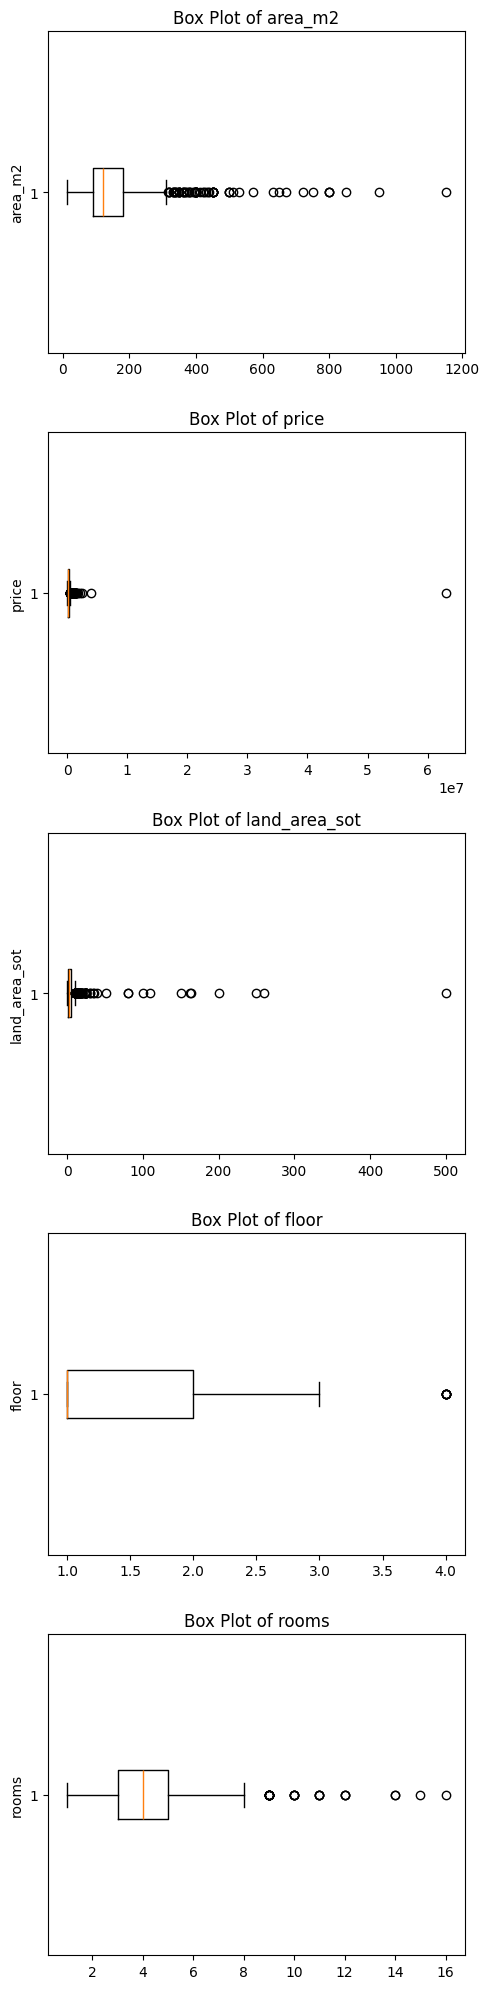

In [25]:
key_numeric_features = ["area_m2", "price", "land_area_sot", "floor", "rooms"]
plot_numeric_distributions(df_clean, key_numeric_features)

In [26]:
df_clean["price"].describe()

count    1.176000e+03
mean     2.745915e+05
std      1.851871e+06
min      8.500000e+03
25%      7.500000e+04
50%      1.250000e+05
75%      2.500000e+05
max      6.300000e+07
Name: price, dtype: float64

In [30]:
df_clean.drop(df_clean[df_clean["price"] == 63000000].index, inplace=True)
df_clean['price'].describe()

count    1.175000e+03
mean     2.212082e+05
std      2.795595e+05
min      8.500000e+03
25%      7.500000e+04
50%      1.250000e+05
75%      2.500000e+05
max      3.900000e+06
Name: price, dtype: float64

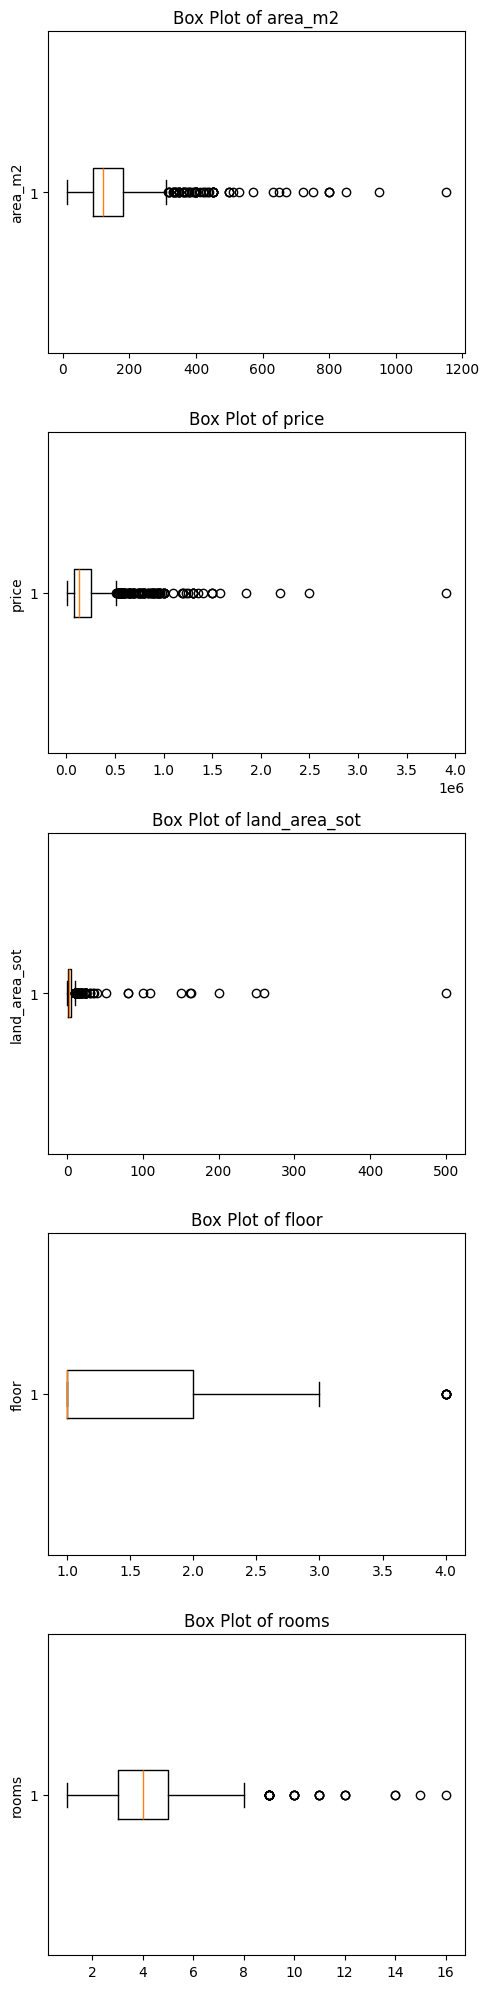

In [31]:
plot_numeric_distributions(df_clean, key_numeric_features)

In [32]:
df_clean.drop(df_clean[df_clean["price"] == 3900000.0].index, inplace=True)
df_clean['price'].describe()

count    1.174000e+03
mean     2.180746e+05
std      2.582108e+05
min      8.500000e+03
25%      7.500000e+04
50%      1.250000e+05
75%      2.497500e+05
max      2.500000e+06
Name: price, dtype: float64

In [ ]:
df_clean['land_area_sot'].describe()

count    1174.000000
mean        5.803501
std        21.348591
min         0.090000
25%         1.500000
50%         2.500000
75%         5.000000
max       500.000000
Name: land_area_sot, dtype: float64

In [34]:
df_clean.drop(df_clean[df_clean["land_area_sot"] == 500].index, inplace=True)
df_clean['land_area_sot'].describe()

count    1173.000000
mean        5.382191
std        15.734866
min         0.090000
25%         1.500000
50%         2.500000
75%         5.000000
max       260.000000
Name: land_area_sot, dtype: float64

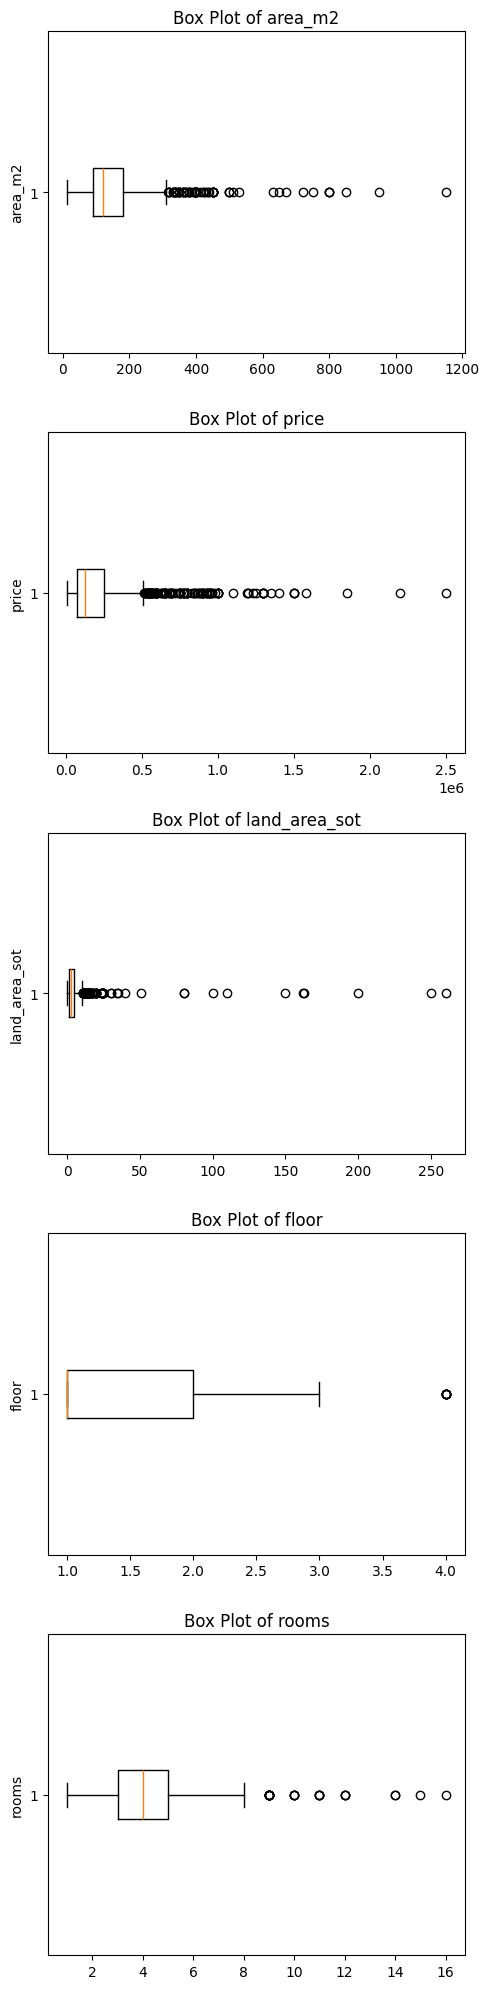

In [35]:
plot_numeric_distributions(df_clean, key_numeric_features)

## Detect and Filter Outliers with IQR
Calculate IQR bounds per numeric feature, filter outliers, and compare dataset size before and after filtering.

In [36]:
def IQR_finding_outliers(df,column):
    Q1 = np.percentile(df[column].dropna(),25)
    Q3 = np.percentile(df[column].dropna(),75)
    IQR = Q3 - Q1 
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound ,upper_bound

for col in key_numeric_features:
    outliers, lower_bound, upper_bound = IQR_finding_outliers(df_clean, col)
    print(f"Column: {col}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"Number of outliers found: {outliers.shape[0]}\n")
    

Column: area_m2
Lower Bound: -45.0, Upper Bound: 315.0
Number of outliers found: 65

Column: price
Lower Bound: -187500.0, Upper Bound: 512500.0
Number of outliers found: 118

Column: land_area_sot
Lower Bound: -3.75, Upper Bound: 10.25
Number of outliers found: 97

Column: floor
Lower Bound: -0.5, Upper Bound: 3.5
Number of outliers found: 7

Column: rooms
Lower Bound: 0.0, Upper Bound: 8.0
Number of outliers found: 26



In [37]:
for col in key_numeric_features:
    outliers, lower_bound, upper_bound = IQR_finding_outliers(df_clean, col)
    df_clean_2 = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]


In [38]:
print("Before outlier removal:", df_clean.shape)
print("After outlier removal:", df_clean_2.shape)
print("Outliers removed:", df_clean.shape[0] - df_clean_2.shape[0])

Before outlier removal: (1173, 25)
After outlier removal: (1147, 25)
Outliers removed: 26


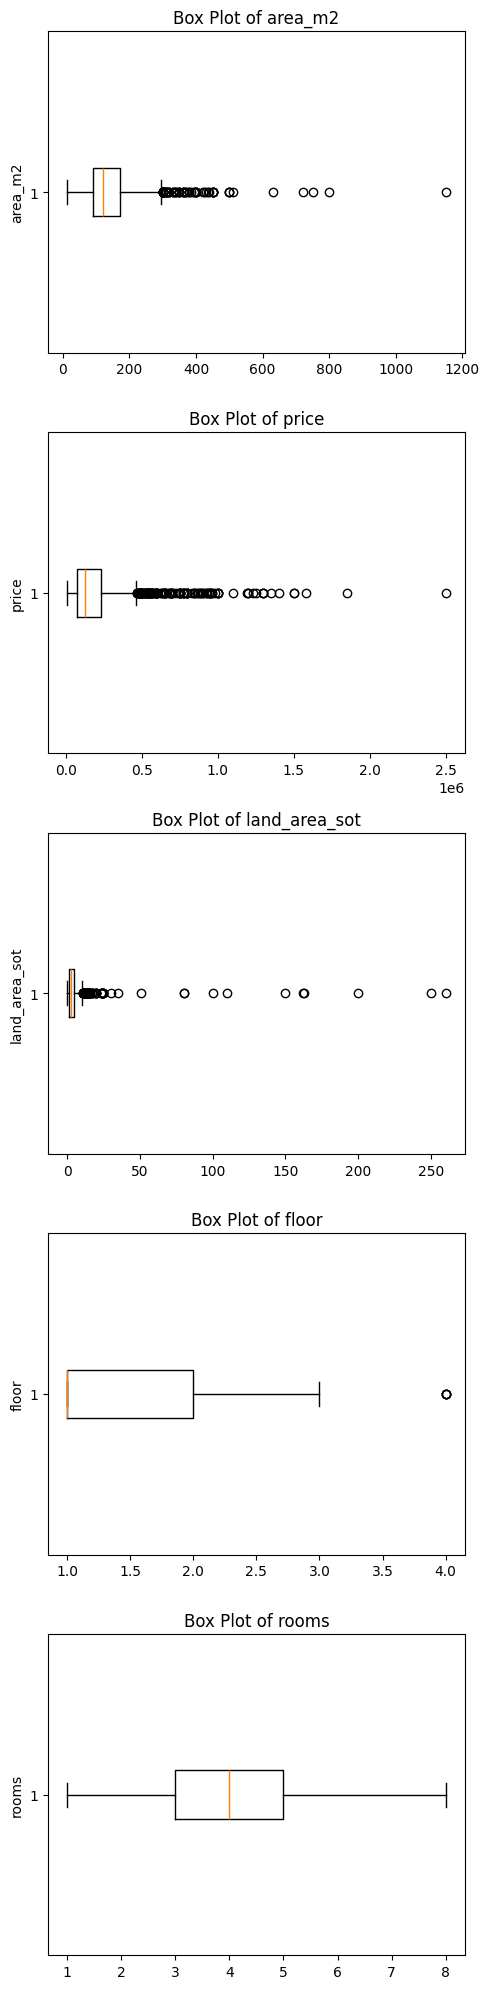

In [39]:
plot_numeric_distributions(df_clean_2, key_numeric_features)

## Final Quality Summary and Export
Summarize cleaning impact, check remaining data quality signals, and save the cleaned house dataset to CSV.

In [40]:
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean_2.shape}")
# - Number of rows removed
print(f"Number of rows removed: {df.shape[0] - df_clean_2.shape[0]}")
# - Number of columns removed
print(f"Number of columns removed: {df.shape[1] - df_clean_2.shape[1]}")
# - Remaining missing values count
print(f"Remaining missing values count: {df_clean_2.isnull().sum().sum()}")
# - Data types value counts
print("Data types value counts:")
print(df_clean_2.dtypes.value_counts())

Original dataset shape: (1176, 25)
Cleaned dataset shape: (1147, 25)
Number of rows removed: 29
Number of columns removed: 0
Remaining missing values count: 0
Data types value counts:
object     20
float64     4
int64       1
Name: count, dtype: int64


In [41]:
df_clean_2.to_csv('../../data/house/satilir_properties_house_cleaned.csv', index=False)
print("Cleaned dataset saved to 'data/house/satilir_properties_house_cleaned.csv'")

Cleaned dataset saved to 'data/house/satilir_properties_house_cleaned.csv'
